# DATA SCIENCE PROJECT 

### How data-driven approaches can support healthcare quality improvement initiatives.

## CRISP-DM Phase 1: Business Understanding

The objective of this project is to identify hospitals at risk of excess readmissions under the CMS Hospital Readmissions Reduction Program (HRRP).


# BUSINESS AND DATA UNDERSTANDING 

Hospital readmissions are a key indicator of healthcare quality and efficiency. High readmission rates often signal gaps in care coordination, discharge planning, or post-hospital follow-up. In addition to their clinical implications, readmissions have a direct financial impact on hospitals.

In the United States, the Centers for Medicare & Medicaid Services (CMS) introduced the Hospital Readmissions Reduction Program (HRRP) to reduce avoidable readmissions. Under this program, hospitals with excess readmissions for specific conditions and procedures may face financial penalties.

**Business Problem**

Hospital administrators and healthcare regulators need to identify hospitals that are at risk of exceeding expected readmission levels. However, understanding which factors contribute to excess readmissions is not always straightforward, as hospitals differ in size, patient case mix, procedures performed, and regional context.

The challenge is to use available hospital-level data to:

- Assess readmission performance relative to expectations, and

- Identify hospitals that may require targeted interventions to reduce readmissions.

**Business Objective**

The main business objective of this project is to support decision-making by identifying hospitals with a high risk of excess readmissions. By doing so, hospitals and policymakers can prioritize preventive actions, improve care quality, and reduce potential financial penalties under the HRRP.

**Key Question**

Can we identify hospitals that are at high risk of excess readmissions based on their clinical, operational, and contextual characteristics?

**Expected Impact**

A reliable readmission risk model can help stakeholders proactively identify high-risk hospitals, allocate resources more effectively, and design interventions aimed at reducing avoidable readmissions. Ultimately, this contributes to improved patient outcomes and more efficient healthcare systems.

## Dataset

**Hospital Readmissions Reduction Program (HRRP) – CMS**

This dataset comes from the Centers for Medicare & Medicaid Services (CMS) and contains information about hospital readmission rates across U.S. hospitals for several medical conditions and procedures. Since 2012, under the Hospital Readmissions Reduction Program (HRRP), hospitals with excess readmissions receive financial penalties, making readmissions both a clinical and economic issue.


In [142]:
import pandas as pd
#function to load datasets
def load_data(filepath):
    return pd.read_csv(filepath)

data = load_data("FY_2025_Hospital_Readmissions_Reduction_Program_Hospital.csv")
data.head()


,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-AMI-HRRP,296.0,NaN,0.9483,13.0146,13.7235,36,07/01/2020,06/30/2023
1,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-CABG-HRRP,151.0,NaN,0.9509,9.6899,10.1898,13,07/01/2020,06/30/2023
2,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HF-HRRP,681.0,NaN,1.0597,21.5645,20.3495,151,07/01/2020,06/30/2023
3,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9654,4.2680,4.4211,Too Few to Report,07/01/2020,06/30/2023
4,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-PN-HRRP,490.0,NaN,0.9715,16.1137,16.5863,77,07/01/2020,06/30/2023


## Business Questions

This analysis is guided by the following business questions related to hospital readmissions and healthcare decision-making.

**Question 1: How are excess readmission rates distributed across hospitals?**

Understanding the overall distribution of excess readmission ratios helps identify how common high-risk hospitals are and whether risk is concentrated or widespread.

**Question 2: Which hospital-level characteristics are most strongly associated with readmission risk?**

Identifying correlations between hospital characteristics and readmission risk helps highlight potential drivers of excess readmissions.

**Question 3: Can predictive models accurately identify hospitals at high risk of excess readmissions?**

This question evaluates whether hospital-level data can be used to reliably classify hospitals as high or low risk.

**Question 4: What factors are most influential in predicting hospital readmission risk?**

Understanding which variables drive model predictions supports transparency and actionable decision-making.

**Question 5: How can this model be applied to a real-world hospital scenario?**

Applying the model to a hypothetical hospital scenario illustrates how predictions could support early interventions before penalties occur.



## CRISP-DM Phase 2: Data Understanding

In this phase, we explore the dataset to understand its structure, key variables, distributions, missing values, and initial relationships.


# 2. EXPLORATORY DATA ANALYSIS (EDA)

### 2.1 DATASET OVERVIEW

In [143]:
data.shape

(18510, 12)

This dataset has 18510 rows and 12 columns.

In [144]:
data.dtypes

Facility Name                     str
Facility ID                     int64
State                             str
Measure Name                      str
Number of Discharges          float64
Footnote                      float64
Excess Readmission Ratio      float64
Predicted Readmission Rate    float64
Expected Readmission Rate     float64
Number of Readmissions            str
Start Date                        str
End Date                          str
dtype: object

As it can be seen in the previous chunk, there are numerical and categorical variables in the dataset. 

INTERPRETATION:

Each row represents a hospital–measure combination under the HRRP program.
The dataset mixes hospital identifiers, clinical measures, readmission metrics, and volume indicators, making it suitable for both descriptive and predictive analysis.

### 2.2 DESCRIPTIVE STATISTICS

In [145]:
data[[
    "Excess Readmission Ratio",
    "Predicted Readmission Rate",
    "Expected Readmission Rate",
    "Number of Discharges"
]].describe()


,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Discharges
count,11927.000000,11927.000000,11927.000000,8340.000000
mean,1.001719,14.995386,14.961234,279.269904
std,0.080547,5.017854,4.871997,266.018069
min,0.477900,1.674200,2.892100,0.000000
25%,0.956550,12.533000,12.612800,115.000000
50%,0.998200,16.060200,16.146000,197.000000
75%,1.043000,18.609000,18.667350,354.000000
max,1.643000,27.809500,25.394200,4501.000000


This table presents summary statistics for the main numerical variables, including readmission ratios, readmission rates, and hospital discharge volumes.

INTERPRETATION:

The descriptive statistics show that the Excess Readmission Ratio is centered around 1, indicating that most hospitals perform close to the expected readmission level. However, there is noticeable variability, with some hospitals exhibiting significantly higher or lower ratios. Readmission rates average around 15%, while the number of discharges varies widely across hospitals, suggesting large differences in hospital size and patient volume.

### 2.3 MISSING VALUES ANALYSIS

In [146]:
data.isnull().sum().sort_values(ascending=False)

Footnote                      11927
Number of Discharges          10170
Predicted Readmission Rate     6583
Excess Readmission Ratio       6583
Expected Readmission Rate      6583
Number of Readmissions         6583
Facility ID                       0
Facility Name                     0
Measure Name                      0
State                             0
Start Date                        0
End Date                          0
dtype: int64

The result above shows the number of missing values each variable has in this dataset. 

- 6,583 rows without readmission metrics (Predicted Readmission Rate, Excess Readmission Ratio, Expected Readmission Rate and Number of Readmissions).

- 10170 missing values in Number of Discharges

- The Footnote variable contains a high number of missing values, as it only provides supplementary reporting information and is not consistently populated across hospitals.

INTERPRETATION:

Missing values are systematic, not random. They are mainly due to CMS suppressing data for hospitals with low case volumes (“Too Few to Report”). This will require filtering or careful handling during data cleaning and modeling.

### 2.4 DISTRIBUTION ANALYSIS

**Question 1: How are excess readmission rates distributed across hospitals?**


Distribution of Excess Readmission Ratio variable

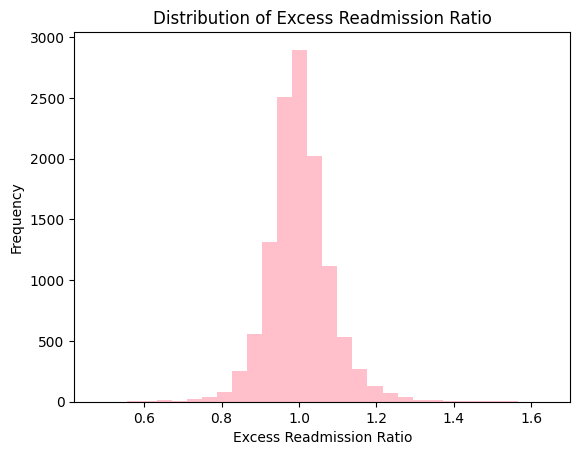

In [147]:
import matplotlib.pyplot as plt

plt.hist(data["Excess Readmission Ratio"].dropna(), bins=30, color="pink")
plt.xlabel("Excess Readmission Ratio")
plt.ylabel("Frequency")
plt.title("Distribution of Excess Readmission Ratio")
plt.show()


In the histogram above it can be seen that the distribution for the "Excess Readmission Ratio" variable is centered around 1 and is approximately symmetric with moderate tails on both sides. 



INTERPRETATION:

Most hospitals have readmission performance close to expectations, but a non-negligible number consistently underperform or overperform relative to expected levels.

Number of discharges variable

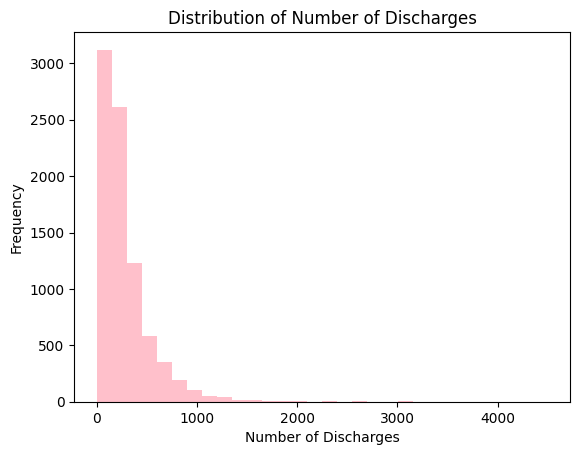

In [148]:
plt.hist(data["Number of Discharges"].dropna(), bins=30,color="pink")
plt.xlabel("Number of Discharges")
plt.ylabel("Frequency")
plt.title("Distribution of Number of Discharges")
plt.show()


In the plot above we can see that the "Number of Discharges" has a strong right skew with many small hospitals and few large hospitals. 



INTERPRETATION:

Hospital volume is highly uneven. This suggests that readmission metrics may be more stable for large hospitals, while smaller hospitals may show higher variability.

### 2.5 OUTLIERS DETECTION

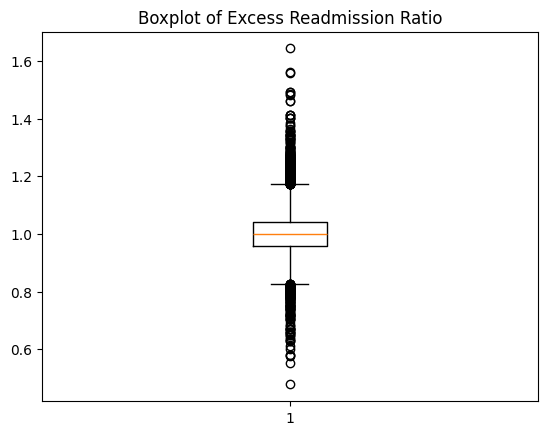

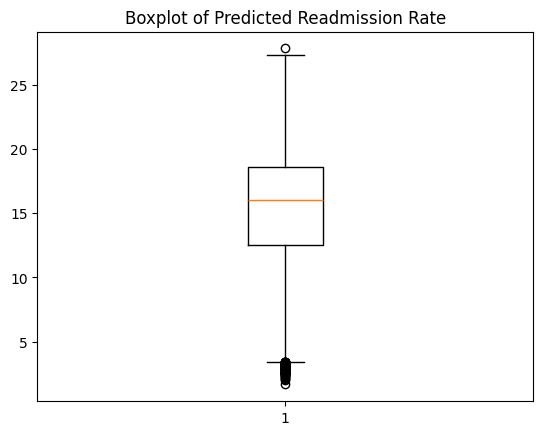

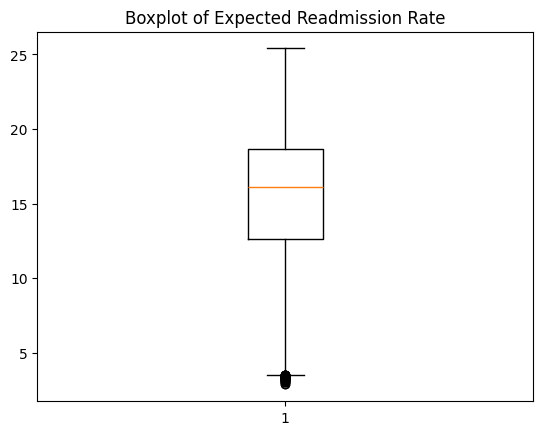

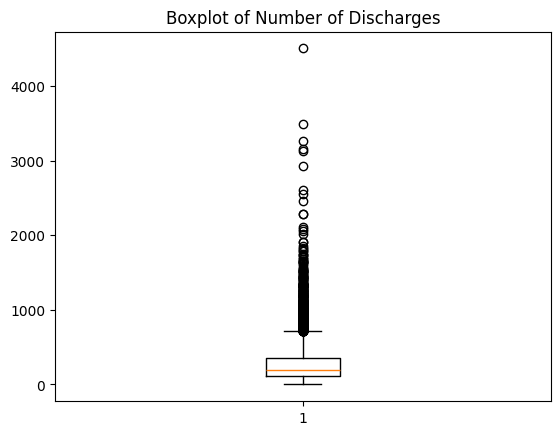

In [149]:
num_vars = [
    "Excess Readmission Ratio",
    "Predicted Readmission Rate",
    "Expected Readmission Rate",
    "Number of Discharges"
]

for var in num_vars:
    plt.figure()
    plt.boxplot(data[var].dropna())
    plt.title(f"Boxplot of {var}")
    plt.show()


Outlier detection was performed on key numerical variables that may influence model performance. Categorical, identifier, and temporal variables were excluded, as outlier analysis is not applicable to these types of data.

INTERPRETATION:

Excess Readmission Ratio: the boxplot reveals outliers at both the lower and upper extremes, representing hospitals with substantially better or worse readmission performance than expected.

Predicted Readmission Rate: outliers appear at both ends of the distribution, indicating hospitals with unusually low or high predicted readmission risk compared to the majority.

Expected Readmission Rate: the presence of outliers suggests that some hospitals serve patient populations with markedly different baseline readmission risk levels.

Number of Discharges: a large number of high-end outliers are observed, corresponding to hospitals with exceptionally high patient volumes relative to most hospitals.

### 2.6 CORRELATION ANALYSIS

**Question 2: Which hospital-level characteristics are most strongly associated with readmission risk?**


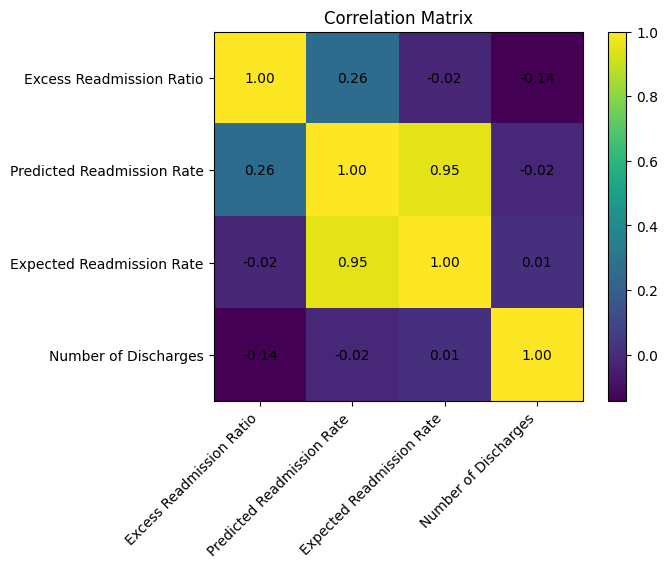

In [150]:
vars_corr = data[[
        "Excess Readmission Ratio",
        "Predicted Readmission Rate",
        "Expected Readmission Rate",
        "Number of Discharges"
    ]
].dropna()

corr = vars_corr.corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.title("Correlation Matrix")
plt.show()


RESULTS (key correlations):

- Predicted vs Expected Readmission Rate: 0.95

- Excess Ratio vs Expected Rate: -0.02

- Excess Ratio vs Discharges: weak negative correlation

INTERPRETATION:

Predicted and expected readmission rates capture similar underlying clinical risk. The excess readmission ratio provides additional information beyond expected risk, making it a suitable target or outcome variable. Hospital volume shows little direct correlation with readmission excess.

EXPLORATORY DATA ANALYSIS SUMMARY:

The exploratory analysis reveals that hospital readmission performance is generally centered around expected levels, but with significant variation across hospitals. Hospital volumes are highly skewed, and missing values are structurally driven by reporting rules. Excess readmission ratios capture deviations not explained by baseline risk, supporting their use in predictive modeling.

## CRISP-DM Phase 3: Data Preparation

This phase includes handling missing values, selecting relevant features, defining the target variable, and preparing the dataset for modeling.


# 3. DATA CLEANING AND FEATURE SELECTION

Before modeling, the dataset requires cleaning.

The goal of this step is to create a clean, consistent modeling dataset while preserving clinically meaningful information.

First, the readmission metrics (Excess Readmission Ratio, Predicted Readmission Rate, Expected Readmission Rate and Number of Readmissions) contain 6583 missing values due to CMS reporting rules ("Too few to Report").

The decision in this part of the project is to remove the rows with missing readmission metrics as these variables are crucial and are central to the analysis and imputation would introduce noise. 

In [151]:
data_clean = data.dropna(
    subset=[
        "Excess Readmission Ratio",
        "Predicted Readmission Rate",
        "Expected Readmission Rate"
    ]
)


Number of Discharges variable also contains a large number of missing values. The decision for this one is that the rows with missing number of discharges are removed for modeling. This is because hospital size is an important contextual feature and imputing will add noise and fake information.

In [152]:
data_clean = data_clean.dropna(subset=["Number of Discharges"])

Finally, the variable footnote also has lots of null values but in this case this variable is removed from the dataset as it stores administrative metadata with no predictive value. 

In [153]:
data_clean = data_clean.drop(columns=["Footnote"])

REMOVING NON-INFORMATIVE VARIABLES

Some of the columns in the dataset will not be used for the project. These are identifier columns such as Facility Name and Facility ID. This two variables are unique identifiers and are not useful for predictive purpose. 


In [154]:
data_clean = data_clean.drop(
    columns=["Facility Name", "Facility ID"]
)

In [155]:
data_clean.head()

,State,Measure Name,Number of Discharges,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,AL,READM-30-AMI-HRRP,296.0,0.9483,13.0146,13.7235,36,07/01/2020,06/30/2023
1,AL,READM-30-CABG-HRRP,151.0,0.9509,9.6899,10.1898,13,07/01/2020,06/30/2023
2,AL,READM-30-HF-HRRP,681.0,1.0597,21.5645,20.3495,151,07/01/2020,06/30/2023
4,AL,READM-30-PN-HRRP,490.0,0.9715,16.1137,16.5863,77,07/01/2020,06/30/2023
5,AL,READM-30-COPD-HRRP,130.0,0.9330,15.4544,16.5637,16,07/01/2020,06/30/2023


**FEATURE SELECTION**

After this long study of the dataset, the finally selected variables to proceed with the project are: State, Measure Name, Number of Discharges, Predicted Readmission Rate and Expected Readmission rate.

The selected features were chosen based on their relevance to hospital readmission performance and their availability across the dataset. Categorical variables such as State and Measure Name capture regional differences and clinical procedure types, which are known to influence readmission patterns. Numerical variables including Number of Discharges represent hospital size and patient volume, while Predicted Readmission Rate and Expected Readmission Rate provide risk-adjusted clinical baselines. Together, these features offer a balanced combination of contextual, clinical, and operational information without introducing data leakage or non-informative identifiers.

**TARGET DEFINITION**

The modeling task in this project can be formulated in two different ways: as a regression problem, where the goal would be to predict the exact value of the excess readmission ratio, or as a classification problem, where the objective is to identify hospitals that exceed the expected level of readmissions.

In this project, the problem is classified as a binary classification task. The target variable, High Readmission Risk, indicates whether a hospital exhibits excess readmissions relative to expectations or not.

The target is defined using the Excess Readmission Ratio, which is the key performance metric used by CMS under the Hospital Readmissions Reduction Program.

In [156]:
#Create binary target variable indicating high readmission risk.

def create_target_variable(df):
    df = df.copy()
    df["high_risk"] = (df["Excess Readmission Ratio"] > 1).astype(int)
    return df

data_clean = create_target_variable(data_clean)


In [157]:
### Identification of categorical variables
data_clean.dtypes

State                             str
Measure Name                      str
Number of Discharges          float64
Excess Readmission Ratio      float64
Predicted Readmission Rate    float64
Expected Readmission Rate     float64
Number of Readmissions            str
Start Date                        str
End Date                          str
high_risk                       int64
dtype: object


The dataset contains both numerical and categorical variables.  
Categorical variables include:

- **State**: U.S. state where the hospital is located  
- **Measure Name**: Type of medical condition or procedure evaluated  

These variables are stored as object (string) types and require special handling before being used in machine learning models.


### Handling of categorical variables

Categorical variables such as **State** and **Measure Name** were intentionally excluded from the modeling stage.

This decision was made for the following reasons:
- The primary objective of the project is to identify hospitals at risk of excess readmissions based on **hospital-level performance metrics**.
- Encoding high-cardinality categorical variables such as State could introduce noise and increase model complexity without clear performance benefits.
- Excluding these variables results in simpler, more interpretable models, which is important in a healthcare decision-making context.

The potential disadvantage of this approach is the loss of geographic or procedure-specific insights. However, these aspects were explored separately during fairness and exploratory analysis rather than included directly in predictive modeling.


A new variable called "high_risk" is created where 1 indicated that the hospital has excess readmissions (actual readmissions exceed expectations) or 0 indicating that the hospital performs at or below the expected readmission level. 

This definition directly reflects the policy threshold used in real-world healthcare evaluation.

**Why classification instead of regression?**

From a business perspective, CMS penalties are triggered when hospitals exceed the expected readmission rate, rather than based on the exact magnitude of the excess. As a result, stakeholders such as hospital administrators and regulators are primarily interested in identifying which hospitals are at risk, rather than predicting a precise numerical ratio. A classification framework aligns more closely with how decisions are made in practice.


From a modeling point of view, classification offers several advantages. It is more robust to extreme values in the excess readmission ratio, which were observed during exploratory analysis. Additionally, classification models are generally easier to interpret and communicate, especially for non-technical stakeholders. 

Finally, the dataset is created to start with the prediction tasks:

In [158]:
def prepare_features_and_target(df):
    X = df.drop(
        columns=[
            "Excess Readmission Ratio",
            "high_risk",
            "Number of Readmissions",
            "Start Date",
            "End Date"
        ]
    )
    y = df["high_risk"]

    return X, y

X, y = prepare_features_and_target(data_clean)
X = pd.get_dummies(X, drop_first=True)



In [159]:
# Verify that all features used for modeling are numerical
X.dtypes


Number of Discharges                   float64
Predicted Readmission Rate             float64
Expected Readmission Rate              float64
State_AL                                  bool
State_AR                                  bool
State_AZ                                  bool
State_CA                                  bool
State_CO                                  bool
State_CT                                  bool
State_DC                                  bool
State_DE                                  bool
State_FL                                  bool
State_GA                                  bool
State_HI                                  bool
State_IA                                  bool
State_ID                                  bool
State_IL                                  bool
State_IN                                  bool
State_KS                                  bool
State_KY                                  bool
State_LA                                  bool
State_MA     

Data cleaning focused on removing structurally missing observations, eliminating non-informative identifiers, and selecting clinically meaningful features. The target variable was defined as a binary indicator of excess readmissions to align the modeling task with real-world policy and decision-making requirements.

## CRISP-DM Phase 4: Modeling

Multiple classification models are trained and evaluated to identify hospitals at high risk of excess readmissions.


# 4. MODEL TRAINING

Before training any model, the dataset is split into training and testing sets to evaluate generalization performance. This split reserves 80% of the data for training and 20% for testing, which is a common practice in supervised learning.

In [160]:
from sklearn.model_selection import train_test_split
# Split data into training and testing sets
# The test set is used only for final model evaluation
def split_train_test(X, y, test_size=0.2, random_state=42):
    return train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state
    )
X_train, X_test, y_train, y_test = split_train_test(X, y)


Now that we have the data prepared for the model training, different models will be applied to this dataset to select the most suitable one for this predictive task. The baseline model will be a logistic regression as it it a simple and widely used classification model and easy to interpret and for comparison.

**Question 3: Can predictive models accurately identify hospitals at high risk of excess readmissions?**

In [161]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
    }



In [162]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


def get_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    }

models = get_models()

In [163]:
def evaluate_all_models(models, X_train, X_test, y_train, y_test):
    results = []

    for model_name, model in models.items():
        metrics = evaluate_model(model, X_train, X_test, y_train, y_test)
        metrics["model"] = model_name
        results.append(metrics)

    return results

results = evaluate_all_models(models, X_train, X_test, y_train, y_test)
results

[{'accuracy': 0.9969230769230769,
  'precision': 0.9956709956709957,
  'recall': 0.998914223669924,
  'f1_score': 0.997289972899729,
  'model': 'Logistic Regression'},
 {'accuracy': 0.9710769230769231,
  'precision': 0.9791666666666666,
  'recall': 0.9695982627578719,
  'f1_score': 0.9743589743589743,
  'model': 'Decision Tree'},
 {'accuracy': 0.9224615384615384,
  'precision': 0.9306608884073673,
  'recall': 0.9326818675352877,
  'f1_score': 0.9316702819956616,
  'model': 'Random Forest'},
 {'accuracy': 0.9636923076923077,
  'precision': 0.9674620390455532,
  'recall': 0.9685124864277959,
  'f1_score': 0.9679869777536625,
  'model': 'Gradient Boosting'}]

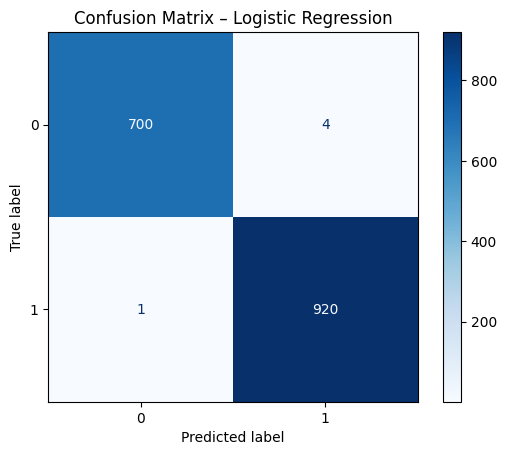

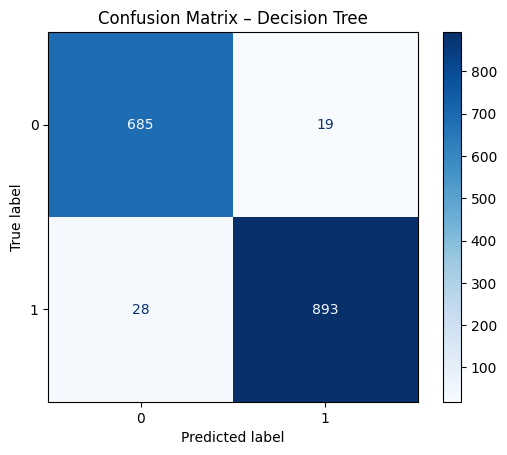

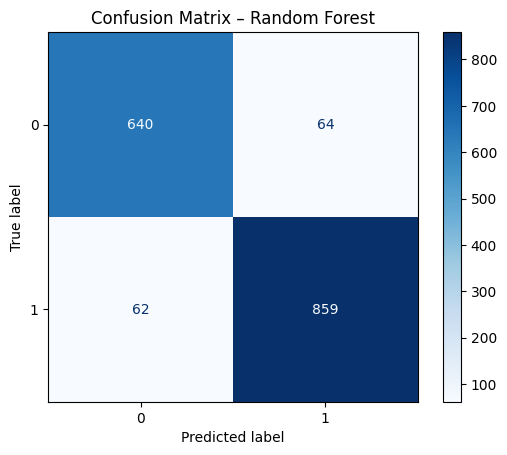

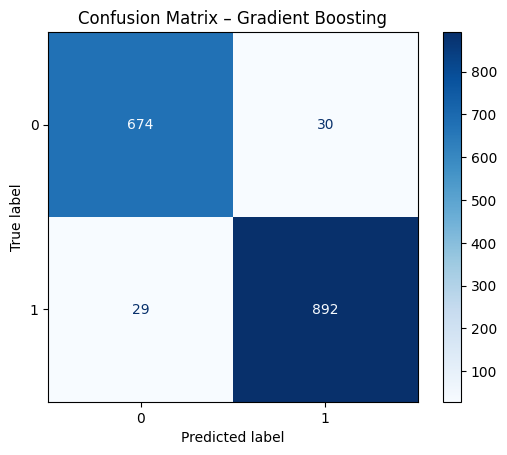

In [164]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#    Plot the confusion matrix for a trained classification model.
def plot_confusion_matrix(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix – {model_name}")
    plt.show()

trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[model_name] = model

for model_name, model in trained_models.items():
    plot_confusion_matrix(model, X_test, y_test, model_name)



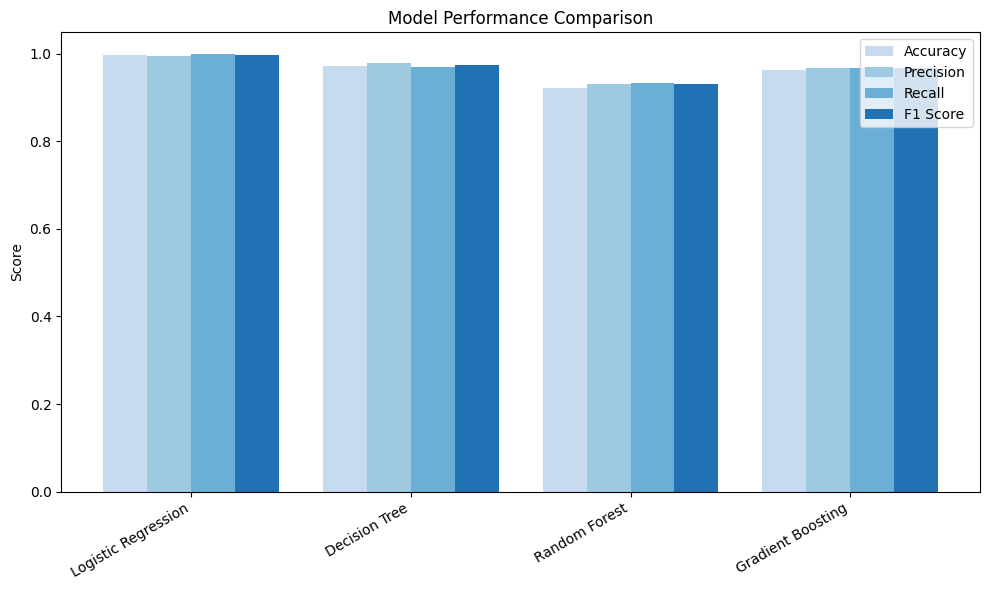

In [165]:
import matplotlib.pyplot as plt
import numpy as np

#    Plot a bar chart comparing model performance metrics.
def plot_model_performance(results_df):

    metrics = ["accuracy", "precision", "recall", "f1_score"]
    model_names = results_df["model"]

    x = np.arange(len(model_names))
    width = 0.2

    blue_colors = ["#c6dbef", "#9ecae1", "#6baed6", "#2171b5"]

    plt.figure(figsize=(10, 6))

    for i, metric in enumerate(metrics):
        plt.bar(
            x + i * width,
            results_df[metric],
            width,
            label=metric.replace("_", " ").title(),
            color=blue_colors[i]
        )

    plt.xticks(x + width * 1.5, model_names, rotation=30, ha="right")
    plt.ylabel("Score")
    plt.title("Model Performance Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_model_performance(results_df)


Each model was evaluated on the same test dataset using standard classification metrics. This allows a fair comparison of performance across different modeling approaches and supports the selection of the most appropriate model.

The table above compares the performance of four classification models using Accuracy, Precision, Recall, and F1 Score.

Logistic Regression achieves the best overal performance across all metrics with very high accuracy and recall, indicating that it correctly identifies almost all hospital with excess readmissions. This suggest that the relationship between the selected features and the target variable is largely linear and well captures by a simple model.


Decision Tree shows high precision but low recall, which means that the model is conservative. When it predicts high risk it is often correct but it misses many high-risk hospitals. This is less suitable for this problem where identifying at-risk hospitals is critical.


Random Forest improves recall compared to the decision tree model but still underperforms to the other models. It provides a balance between precision and recall but the overall performance remains moderate. Adding complexity does not necesarily improve results for this dataset. 


Gradient Boosting has strong performance across metrics with high accuracy and F1 score. It performs slightly worse than the logistic regression but still demostrates excellent predictive capability. 

Comparing the confusion matrices confirms that Logistic Regression and Gradient Boosting provide the most reliable identification of hospitals with excess readmissions

Logistic Regression is selected as the final model due to its superior performance across all evaluation metrics, combined with its simplicity and interpretability.

This choice is further justified because:

- It achieves the highest Recall, minimizing the risk of missing hospitals with excess readmissions.

- It is easier to explain to non-technical stakeholders.

- It aligns well with the policy-driven nature of the problem

Overall, results indicate that a well-defined linear decision boundary is sufficient to accurately identify hospitals at risk of excess readmissions.

## CRISP-DM Phase 5: Evaluation

Model performance is evaluated using classification metrics, confusion matrices, and interpretability techniques to assess usefulness and limitations.


# 5. MODEL INTERPRETABILITY AND FAIRNESS

After selecting Logistic Regression as the final model, interpretability becomes a key requirement. In a healthcare and policy context, it is essential to understand which factors drive predictions and whether the model behaves consistently across different groups.

**MODEL COEFFICIENTS**

In [166]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coefficients


,Feature,Coefficient
1,Predicted Readmission Rate,12.537279
8,State_CT,0.707149
3,State_AL,0.486807
56,Measure Name_READM-30-HIP-KNEE-HRRP,0.448947
22,State_MD,0.438230
13,State_HI,0.389718
19,State_KY,0.380158
5,State_AZ,0.278740
42,State_SC,0.166275
52,State_WY,0.165485


Positive coefficients increase the likelihood of a hospital being classified as high risk, while negative coefficients decrease that likelihood. This allows direct interpretation of how each variable influences the prediction.

**FEATURE IMPORTANCE**

**Question 4: What factors are most influential in predicting hospital readmission risk?**

Although Logistic Regression is the final model, feature importance from Random Forest is used as a complementary interpretability method.

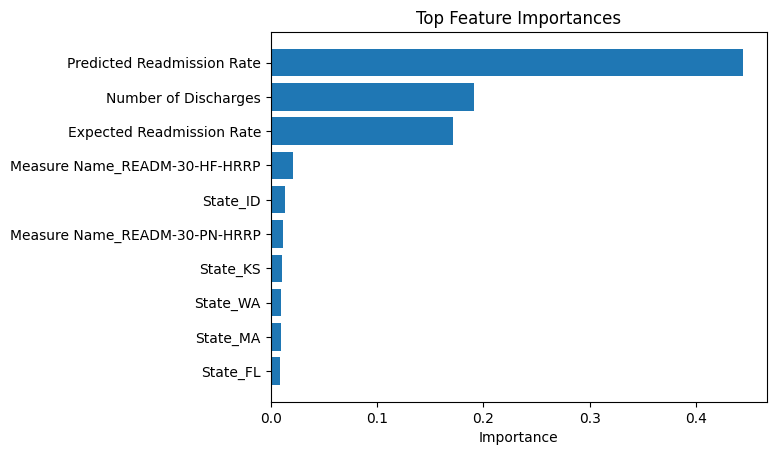

In [167]:
import matplotlib.pyplot as plt

#feature importance for the model to see the most influential variables in the model
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure()
plt.barh(importances.head(10).index, importances.head(10).values)
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()


**SHAPLEY VALUES**

SHAP values are used to explain individual predictions and global feature impact, following the approach introduced in the course.

In [168]:
import shap
import numpy as np

X_background = shap.sample(X_train, 100)
explainer = shap.KernelExplainer(
    log_reg.predict_proba,
    X_background
)
shap_values = explainer.shap_values(X_test[:100])




100%|██████████| 100/100 [00:36<00:00,  2.71it/s]


In [169]:
shap_exp = shap.Explanation(
    values=shap_values[1],
    base_values=explainer.expected_value[1],
    data=X_test[:100].values,
    feature_names=X_test.columns
)


Due to technical limitations in the execution environment, SHAP visualizations could not be reliably produced. Interpretability was therefore primarily assessed using model coefficients and tree-based feature importance, which provide transparent and policy-relevant insights for this classification task.

**FAIRNESS CONSIDERATIONS**

In [170]:
fairness_df = X_test.copy()
fairness_df["Prediction"] = log_reg.predict(X_test)
fairness_df["State"] = data_clean.loc[X_test.index, "State"]

fairness_df.groupby("State")["Prediction"].mean().sort_values().head()


State
WY    0.000000
SD    0.000000
DE    0.166667
UT    0.166667
DC    0.200000
Name: Prediction, dtype: float64

Differences in predicted high-risk rates across states suggest potential regional disparities, highlighting the importance of monitoring fairness when deploying predictive models in healthcare.

Overall, interpretability analyses indicate that the model relies primarily on clinically and operationally meaningful features. Risk-adjusted variables such as Predicted Readmission Rate and Expected Readmission Rate, along with Number of Discharges, emerge as the most influential predictors, suggesting that hospital readmission risk is largely driven by baseline patient risk and hospital volume rather than geographic identifiers. Feature importance from the Random Forest model reinforces this finding, as state-level and procedure-specific variables contribute relatively little to the final predictions. From a fairness perspective, predicted high-risk rates vary across states, but these differences are modest and likely reflect structural and contextual factors rather than systematic bias. While no direct evidence of unfair treatment is observed, the results highlight the importance of continuous monitoring to ensure equitable model behavior across regions when applied in real-world healthcare decision-making.

# 6. SCENARIO AND PREDICTION

**Question 5: How can this model be applied to a real-world hospital scenario?**

To illustrate how the model can be used in practice, we consider a realistic scenario representing a single hospital. Instead of creating artificial values, an observation from the test dataset is selected to ensure that the scenario reflects real hospital characteristics observed in the data.

This approach demonstrates how the trained model would be applied to a new hospital in a real-world setting.

In [171]:
# new scenario and new use case

scenario = X_test.iloc[[0]]

scenario_prediction = log_reg.predict(scenario)[0]
scenario_probability = log_reg.predict_proba(scenario)[0, 1]

scenario_prediction, scenario_probability


(np.int64(1), np.float64(0.9184073301880452))

Prediction Interpretation

Prediction = 1 indicates that the hospital is classified as high risk of excess readmissions.

Prediction = 0 indicates that the hospital is classified as low or expected readmission risk.

The predicted probability represents the model’s confidence that the hospital will experience excess readmissions.

This scenario represents a hospital with specific clinical and operational characteristics, such as patient volume, procedure type, and baseline readmission risk. The model predicts a high probability of excess readmissions, suggesting that this hospital may be at risk of future penalties under the Hospital Readmissions Reduction Program. In a real-world context, this information could be used by hospital administrators to prioritize preventive actions aimed at reducing readmissions.

This example demonstrates how the model can support decision-making by identifying hospitals that may require targeted interventions, translating predictive analytics into actionable insights for healthcare stakeholders.